ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/project/def-nahee/kbas/.venv_try/lib64/python3.9/site-packages/traitlets/traitlets.py", line 668, in get
    value = self._vali

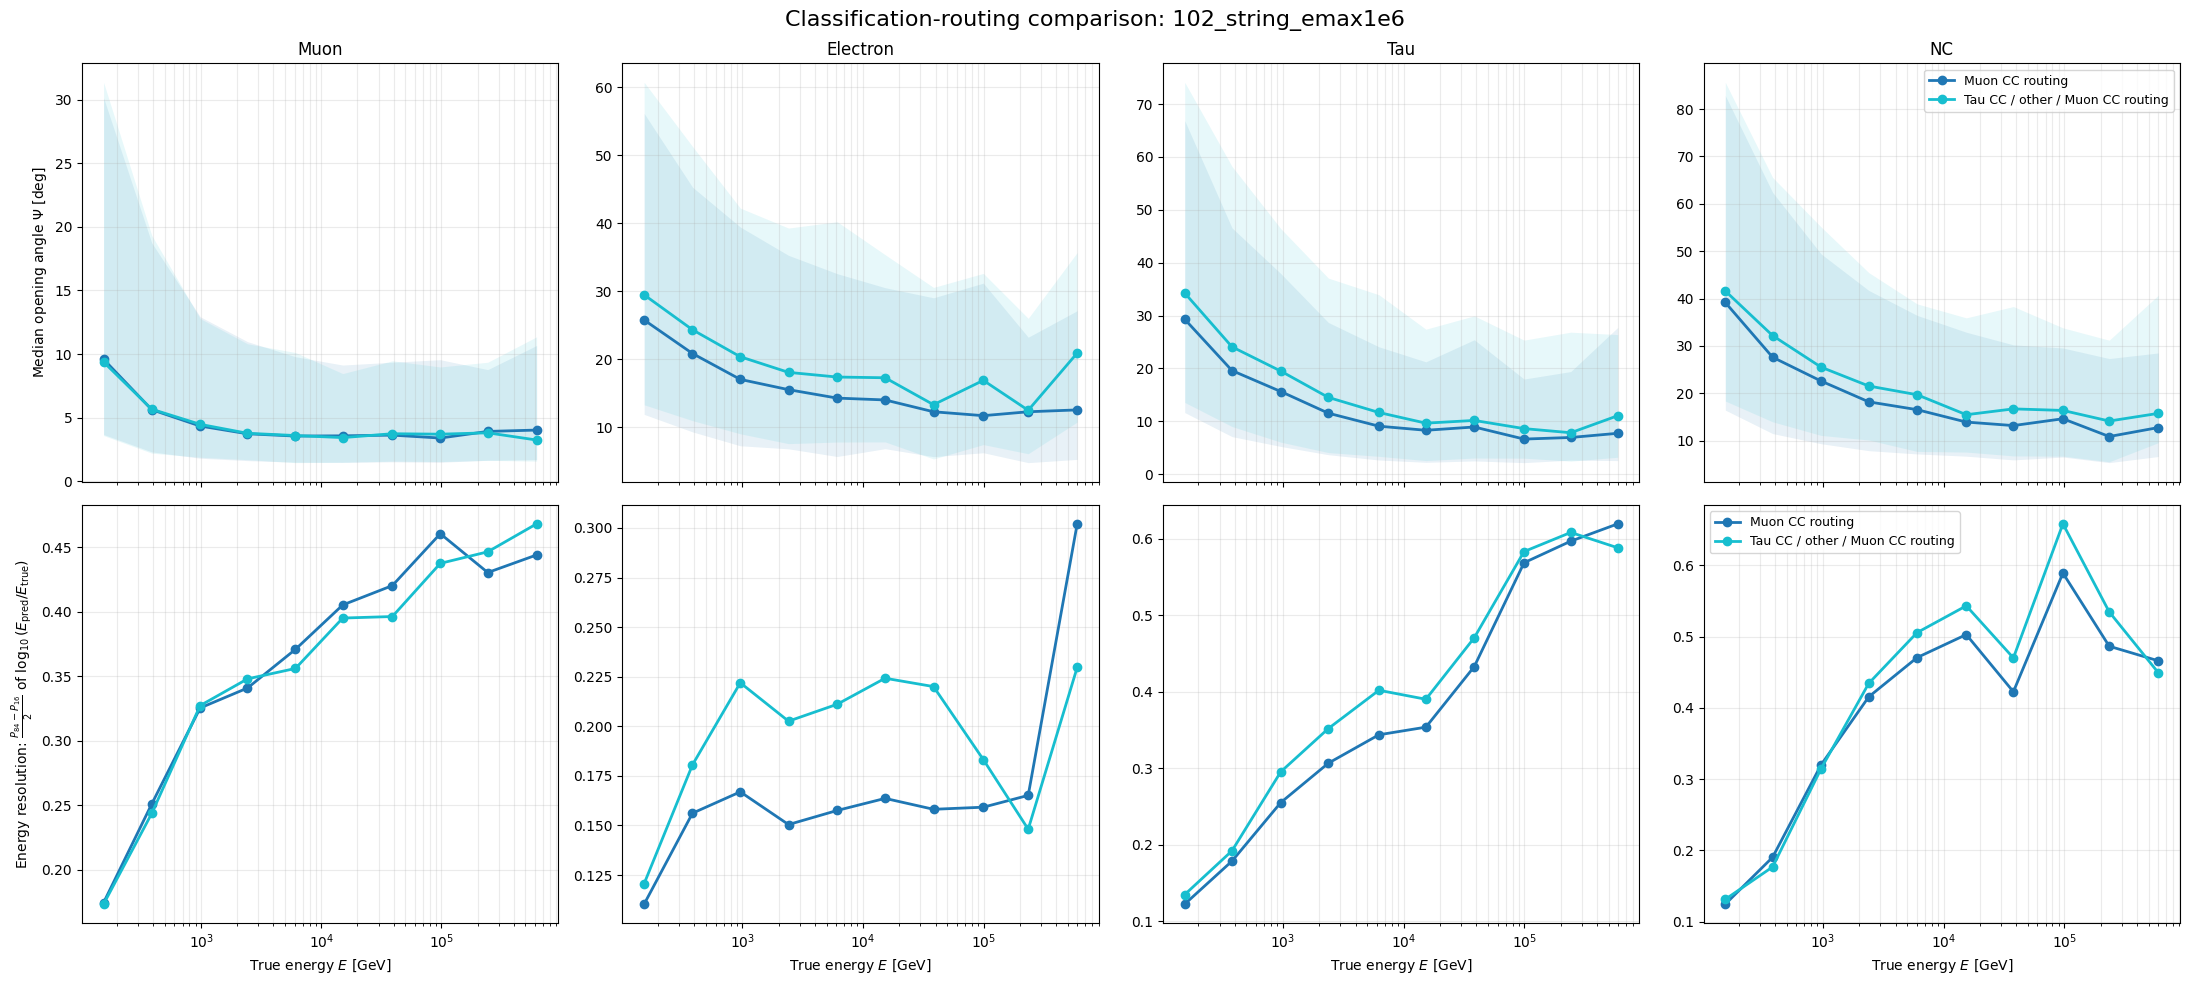

,bin_center_log10,count,opening_median,opening_p16,opening_p84,energy_resolution,bin_center_energy,geometry,category,flavor
0,2.188205,5428,9.588418,3.674016,30.144439,0.174530,154.242675,102_string_emax1e6,category1_isMuonCC,Muon
1,2.589002,4132,5.626789,2.309338,18.733661,0.251043,388.152549,102_string_emax1e6,category1_isMuonCC,Muon
2,2.992026,3345,4.339730,1.811576,12.933007,0.325449,981.806900,102_string_emax1e6,category1_isMuonCC,Muon
3,3.385779,2639,3.732220,1.622641,10.974612,0.340885,2430.964399,102_string_emax1e6,category1_isMuonCC,Muon
4,3.785181,1815,3.552399,1.498317,9.787177,0.370890,6097.912048,102_string_emax1e6,category1_isMuonCC,Muon


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_ROOT = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC")
DEFAULT_EXPERIMENT = "baseline"
DEFAULT_FLAVORS = ["Muon", "Electron", "Tau", "NC"]

CATEGORY_LABELS = {
    "category1_isMuonCC": "Muon CC routing",
    "category2_tauCC_others_muonCC": "Tau CC / other / Muon CC routing",
    "category_3_contains_muon": "Contains-muon routing",
}


def _prediction_path(geometry, category, experiment_name=DEFAULT_EXPERIMENT):
    return (
        RESULTS_ROOT
        / geometry
        / "inference"
        / category
        / experiment_name
        / "inference"
        / "inference_predictions.csv"
    )


def _opening_angle_deg(theta_true, phi_true, theta_pred, phi_pred):
    cos_delta = (
        np.sin(theta_true) * np.sin(theta_pred) * np.cos(phi_true - phi_pred)
        + np.cos(theta_true) * np.cos(theta_pred)
    )
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))


def _sigma68(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return 0.5 * (np.percentile(values, 84) - np.percentile(values, 16))


def _add_flavor(frame):
    frame = frame.copy()
    pid_flavor = frame["pid"].abs().astype("Int64").map(
        {12: "Electron", 14: "Muon", 16: "Tau"}
    )
    frame["flavor"] = np.where(
        frame["is_CC"].astype("Int64") == 0,
        "NC",
        pid_flavor,
    )
    return frame.dropna(subset=["flavor"])


def _prepare_predictions(geometry, category, experiment_name):
    path = _prediction_path(geometry, category, experiment_name)
    if not path.is_file():
        raise FileNotFoundError(f"Inference predictions not found: {path}")

    frame = pd.read_csv(path)
    required = {
        "event_key", "pid", "is_CC", "true_energy", "pred_energy",
        "true_zenith_radian", "pred_zenith_radian",
        "true_azimuth_radian", "pred_azimuth_radian",
    }
    missing = sorted(required.difference(frame.columns))
    if missing:
        raise KeyError(f"{category} is missing required columns: {missing}")
    if not frame["event_key"].is_unique:
        raise ValueError(f"{category} contains duplicate event_key values")

    frame = _add_flavor(frame)
    frame["true_log10_energy"] = np.log10(frame["true_energy"])
    frame["energy_log10_residual"] = np.log10(frame["pred_energy"] / frame["true_energy"])
    frame["opening_angle_degree"] = _opening_angle_deg(
        frame["true_zenith_radian"],
        frame["true_azimuth_radian"],
        frame["pred_zenith_radian"],
        frame["pred_azimuth_radian"],
    )
    return frame


def _binned_summary(frame, energy_edges):
    work = frame.replace([np.inf, -np.inf], np.nan).dropna(
        subset=["true_log10_energy", "opening_angle_degree", "energy_log10_residual"]
    ).copy()
    work["energy_bin"] = pd.cut(
        work["true_log10_energy"], bins=energy_edges, include_lowest=True
    )
    summary = (
        work.groupby("energy_bin", observed=True)
        .agg(
            bin_center_log10=("true_log10_energy", "mean"),
            count=("event_key", "size"),
            opening_median=("opening_angle_degree", "median"),
            opening_p16=("opening_angle_degree", lambda x: np.percentile(x, 16)),
            opening_p84=("opening_angle_degree", lambda x: np.percentile(x, 84)),
            energy_resolution=("energy_log10_residual", _sigma68),
        )
        .reset_index(drop=True)
    )
    summary["bin_center_energy"] = 10 ** summary["bin_center_log10"]
    return summary


def compare_classification_approaches(
    geometry,
    categories,
    experiment_name=DEFAULT_EXPERIMENT,
    n_energy_bins=10,
    category_labels=None,
):
    """Compare routed reconstruction performance for two or more classifiers."""
    categories = list(dict.fromkeys(categories))
    if len(categories) < 2:
        raise ValueError("Provide at least two distinct category names")

    frames = {
        category: _prepare_predictions(geometry, category, experiment_name)
        for category in categories
    }

    reference_category = categories[0]
    reference_keys = set(frames[reference_category]["event_key"])
    for category in categories[1:]:
        keys = set(frames[category]["event_key"])
        if keys != reference_keys:
            raise ValueError(
                f"Event sets differ between {reference_category} and {category}: "
                f"reference={len(reference_keys):,}, current={len(keys):,}, "
                f"missing={len(reference_keys - keys):,}, extra={len(keys - reference_keys):,}"
            )

    all_log_energy = pd.concat(
        [frame["true_log10_energy"] for frame in frames.values()], ignore_index=True
    ).replace([np.inf, -np.inf], np.nan).dropna()
    energy_edges = np.linspace(all_log_energy.min(), all_log_energy.max(), n_energy_bins + 1)

    labels = dict(CATEGORY_LABELS)
    if category_labels:
        labels.update(category_labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))

    fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex="col")
    summaries = []

    for col, flavor in enumerate(DEFAULT_FLAVORS):
        for color, category in zip(colors, categories):
            flavor_frame = frames[category][frames[category]["flavor"] == flavor]
            summary = _binned_summary(flavor_frame, energy_edges)
            summary["geometry"] = geometry
            summary["category"] = category
            summary["flavor"] = flavor
            summaries.append(summary)

            label = labels.get(category, category)
            axes[0, col].plot(
                summary["bin_center_energy"],
                summary["opening_median"],
                marker="o", linewidth=2, color=color, label=label,
            )
            axes[0, col].fill_between(
                summary["bin_center_energy"],
                summary["opening_p16"],
                summary["opening_p84"],
                color=color, alpha=0.10, linewidth=0,
            )
            axes[1, col].plot(
                summary["bin_center_energy"],
                summary["energy_resolution"],
                marker="o", linewidth=2, color=color, label=label,
            )

        axes[0, col].set_title(flavor)
        axes[0, col].set_xscale("log")
        axes[1, col].set_xscale("log")
        axes[0, col].grid(True, alpha=0.25, which="both")
        axes[1, col].grid(True, alpha=0.25, which="both")
        axes[1, col].set_xlabel(r"True energy $E$ [GeV]")

    axes[0, 0].set_ylabel(r"Median opening angle $\Psi$ [deg]")
    axes[1, 0].set_ylabel(r"Energy resolution: $\frac{P_{84}-P_{16}}{2}$ of $\log_{10}(E_\mathrm{pred}/E_\mathrm{true})$")
    axes[0, -1].legend(loc="best", fontsize=9)
    axes[1, -1].legend(loc="best", fontsize=9)
    fig.suptitle(f"Classification-routing comparison: {geometry}", fontsize=16)
    fig.tight_layout()
    plt.show()

    return pd.concat(summaries, ignore_index=True)


comparison_summary = compare_classification_approaches(
    geometry="102_string_emax1e6",
    categories=[
        "category1_isMuonCC",
        "category2_tauCC_others_muonCC",
    ],
)
comparison_summary.head()
